In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score


In [3]:
df = pd.read_csv('pulsar_stars.csv')

print(df.head())
print(df['target_class'].value_counts(normalize=True)) # Confirm the ~90/10 imbalance

    Mean of the integrated profile  \
0                       140.562500   
1                       102.507812   
2                       103.015625   
3                       136.750000   
4                        88.726562   

    Standard deviation of the integrated profile  \
0                                      55.683782   
1                                      58.882430   
2                                      39.341649   
3                                      57.178449   
4                                      40.672225   

    Excess kurtosis of the integrated profile  \
0                                   -0.234571   
1                                    0.465318   
2                                    0.323328   
3                                   -0.068415   
4                                    0.600866   

    Skewness of the integrated profile   Mean of the DM-SNR curve  \
0                            -0.699648                   3.199833   
1                        

In [4]:
# separating features x and target y

X = df.drop('target_class', axis = 1)
y = df['target_class']

# Stratified split: 'stratify=y' ensures 10% pulsars in both train and test sets

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, random_state = 42, stratify=y)

# Scale the features so all metrics have equal weight

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
# Initialize and train the model

log_reg = LogisticRegression(class_weight='balanced', random_state = 42)
log_reg.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [6]:
# Get the probability of being class 1 (Pulsar)
# [:, 1] grabs the probabilities for the positive class only
y_pred_probs = log_reg.predict_proba(X_test_scaled)[:, 1]

# Define a range of thresholds to test (from 0.1 to 0.9)
thresholds = np.arange(0.001, 1.0, 0.005)

best_threshold = 0.5
best_f1 = 0

for thresh in thresholds:
    # Convert probabilities to 1 if above threshold, else 0
    y_pred_custom = (y_pred_probs >= thresh).astype(int)
    
    # Calculate F1-Score for this threshold
    current_f1 = f1_score(y_test, y_pred_custom)
    
    # Track the best performing threshold
    if current_f1 > best_f1:
        best_f1 = current_f1
        best_threshold = thresh

print(f"Optimal Classification Threshold: {best_threshold:.2f}")
print(f"Maximum F1-Score Achieved: {best_f1:.4f}")

Optimal Classification Threshold: 0.84
Maximum F1-Score Achieved: 0.8969



--- Final Model Performance ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3252
           1       0.92      0.88      0.90       328

    accuracy                           0.98      3580
   macro avg       0.95      0.93      0.94      3580
weighted avg       0.98      0.98      0.98      3580



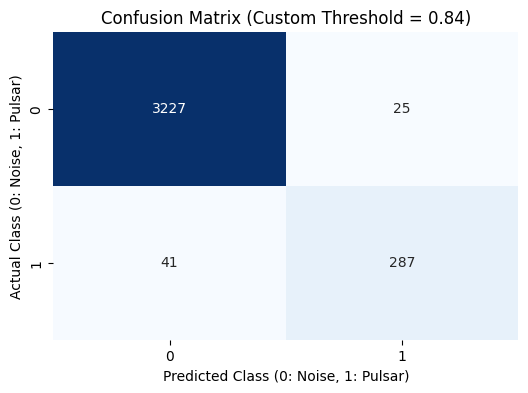

In [7]:
# Apply your new, custom threshold to get final predictions
final_predictions = (y_pred_probs >= best_threshold).astype(int)

print("\n--- Final Model Performance ---")
print(classification_report(y_test, final_predictions))

# Visualize the Confusion Matrix
cm = confusion_matrix(y_test, final_predictions)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Confusion Matrix (Custom Threshold = {best_threshold:.2f})')
plt.ylabel('Actual Class (0: Noise, 1: Pulsar)')
plt.xlabel('Predicted Class (0: Noise, 1: Pulsar)')
plt.show()

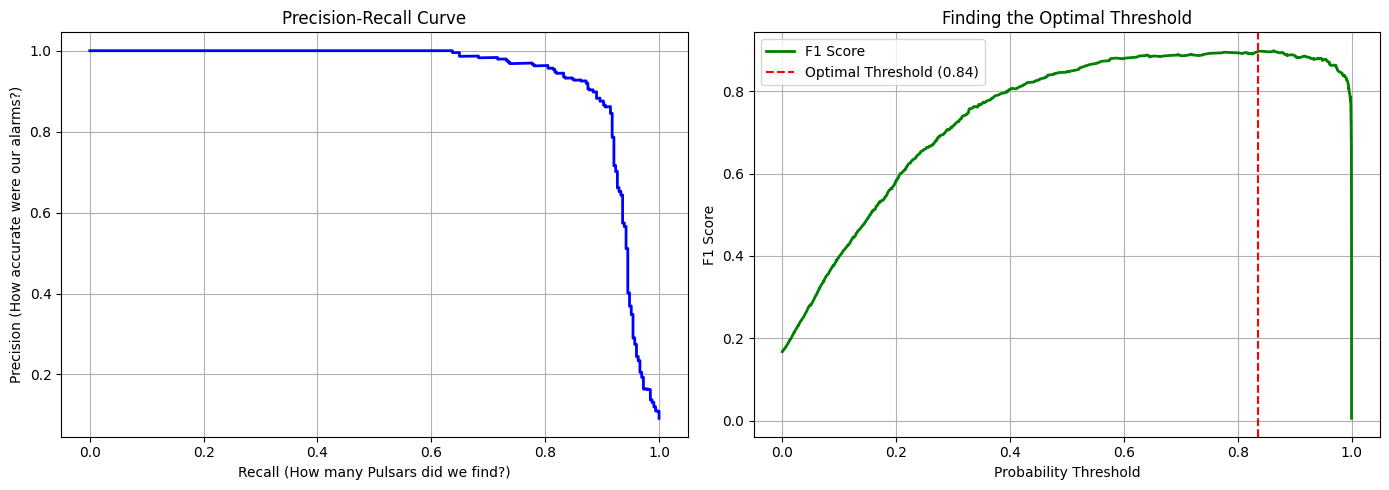

In [8]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# 1. Calculate precisions, recalls, and thresholds
precisions, recalls, thresholds_pr = precision_recall_curve(y_test, y_pred_probs)

# Calculate F1 scores across the thresholds
# (We add a tiny number to the denominator to avoid dividing by zero)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)

# Set up the plotting area
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Precision-Recall Curve ---
ax1.plot(recalls, precisions, 'b-', linewidth=2)
ax1.set_xlabel('Recall (How many Pulsars did we find?)')
ax1.set_ylabel('Precision (How accurate were our alarms?)')
ax1.set_title('Precision-Recall Curve')
ax1.grid(True)

# --- Plot 2: F1 Score vs. Threshold ---
# Note: precision_recall_curve returns one less threshold than precisions/recalls
ax2.plot(thresholds_pr, f1_scores[:-1], 'g-', linewidth=2, label='F1 Score')
ax2.axvline(x=best_threshold, color='r', linestyle='--', 
            label=f'Optimal Threshold ({best_threshold:.2f})')
ax2.set_xlabel('Probability Threshold')
ax2.set_ylabel('F1 Score')
ax2.set_title('Finding the Optimal Threshold')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

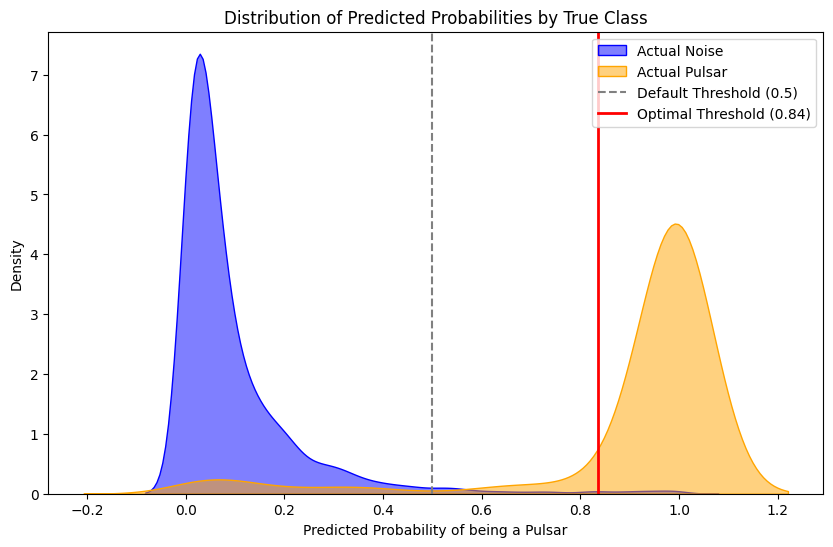

In [9]:
plt.figure(figsize=(10, 6))

# Plot the probability distribution for Actual Noise (Class 0)
sns.kdeplot(y_pred_probs[y_test == 0], label='Actual Noise', fill=True, color='blue', alpha=0.5)

# Plot the probability distribution for Actual Pulsars (Class 1)
sns.kdeplot(y_pred_probs[y_test == 1], label='Actual Pulsar', fill=True, color='orange', alpha=0.5)

# Add threshold lines
plt.axvline(x=0.5, color='gray', linestyle='--', label='Default Threshold (0.5)')
plt.axvline(x=best_threshold, color='red', linestyle='-', linewidth=2, label=f'Optimal Threshold ({best_threshold:.2f})')

plt.title('Distribution of Predicted Probabilities by True Class')
plt.xlabel('Predicted Probability of being a Pulsar')
plt.ylabel('Density')
plt.legend()
plt.show()

C:\Users\nirno\AppData\Local\Temp\ipykernel_3396\4269872765.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')


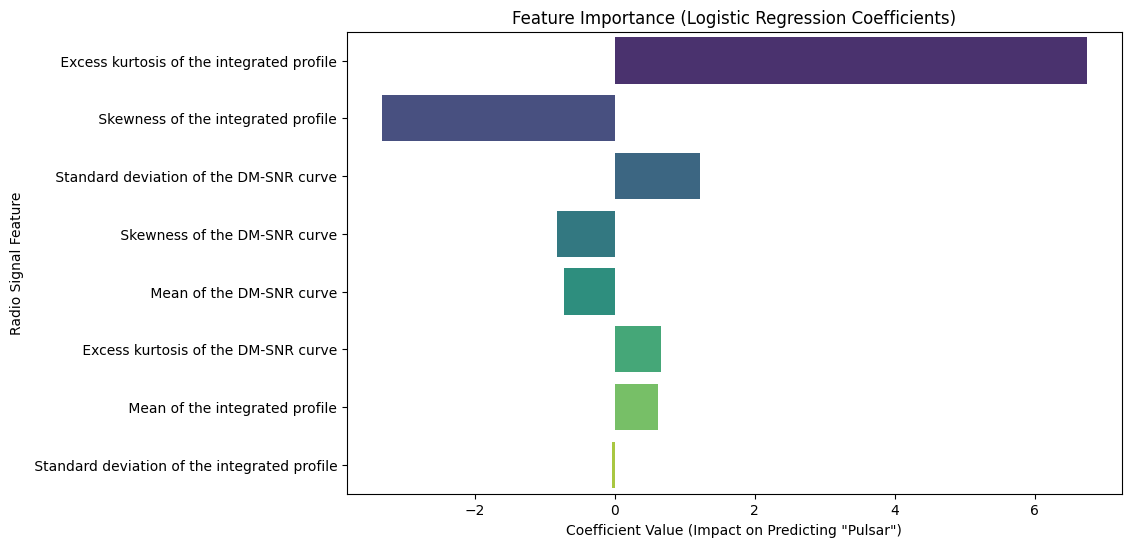

In [13]:
# Get the coefficients from the trained model
importance = log_reg.coef_[0]

# Create a DataFrame for easy plotting
feature_names = X.columns
feature_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importance})

# Sort by absolute value to see the most impactful features at the top
feature_importance['Abs_Importance'] = feature_importance['Importance'].abs()
feature_importance = feature_importance.sort_values(by='Abs_Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')
plt.title('Feature Importance (Logistic Regression Coefficients)')
plt.xlabel('Coefficient Value (Impact on Predicting "Pulsar")')
plt.ylabel('Radio Signal Feature')
plt.show()

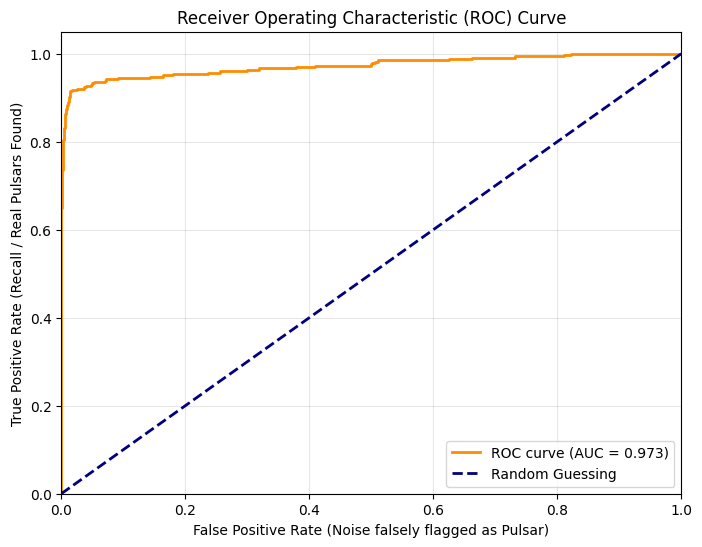

In [14]:
from sklearn.metrics import roc_curve, roc_auc_score

# Calculate False Positive Rate, True Positive Rate, and the AUC score
fpr, tpr, roc_thresholds = roc_curve(y_test, y_pred_probs)
auc_score = roc_auc_score(y_test, y_pred_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guessing')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Noise falsely flagged as Pulsar)')
plt.ylabel('True Positive Rate (Recall / Real Pulsars Found)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

In [15]:
import joblib

# Save the trained model
joblib.dump(log_reg, 'pulsar_model.pkl')

# Save the fitted scaler
joblib.dump(scaler, 'pulsar_scaler.pkl')

print("Model and Scaler successfully saved!")

Model and Scaler successfully saved!
